# Nike Global — Exploratory Data Analysis
Quick look at the data and data quality checks.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:,.2f}'.format)

## 1. Load Data

In [6]:
FILE = 'datasets/Global_Nike.csv'

df = pd.read_csv(FILE)
print(f'Shape: {df.shape[0]:,} rows × {df.shape[1]} columns')
df.head()

Shape: 1,447,795 rows × 35 columns


,snapshot_date,country_code,product_name,model_number,currency,price_local,sale_price_local,gender_segment,size_label,category,subcategory,product_id,sku,style_color,brand_name,color_name,size_count,available_size_count,available,availability_level,available_market,in_stock,discount_pct,employee_price,product_url,canonical_url,image_url,gtin,stock_keeping_unit_id,catalog_sku_id,nike_size,localized_size,size_conversion_id,sport_tags,record_source
0,2026-03-19,US,"""Grateful Duck""",NIKGD001K01,USD,110.00,NaN,MEN,L,APPAREL,Men's Tie-Dye Crew-Neck Sweatshirt,7148e4a5-6073-4816-b7af-7c91f09a292b,274cb3a7-420a-5e11-841e-24ef98973cdd,NIKGD001K01-TYD,Nike,Multi-Color,NaN,NaN,False,OOS,True,True,0.00,NaN,https://www.nike.com/t/grateful-duck-mens-tie-...,https://www.nike.com/t/grateful-duck-mens-tie-...,https://secure-images.nike.com/is/image/DotCom...,NaN,"1,006,750,772.00",39559a5b-10fa-3043-b76d-3768a55e1497,L,L,634c88b1-1341-378c-91c2-694b4d4af924,Football,thread_exact
1,2026-03-19,US,"""Grateful Duck""",NIKGD001K01,USD,110.00,NaN,MEN,M,APPAREL,Men's Tie-Dye Crew-Neck Sweatshirt,7148e4a5-6073-4816-b7af-7c91f09a292b,fbf4c6e3-4080-50f1-b43f-94f44f82581d,NIKGD001K01-TYD,Nike,Multi-Color,NaN,NaN,True,LOW,True,True,0.00,NaN,https://www.nike.com/t/grateful-duck-mens-tie-...,https://www.nike.com/t/grateful-duck-mens-tie-...,https://secure-images.nike.com/is/image/DotCom...,NaN,"1,006,751,435.00",c86c12ba-1f5a-35e9-b7b1-4b99c951697a,M,M,cb181d5c-38b4-3423-a1a4-aa7d8c6f0bc7,Football,thread_exact
2,2026-03-19,US,"""Grateful Duck""",NIKGD001K01,USD,110.00,NaN,MEN,S,APPAREL,Men's Tie-Dye Crew-Neck Sweatshirt,7148e4a5-6073-4816-b7af-7c91f09a292b,34fd4f0f-046a-5b60-96d4-ffacb3a9268d,NIKGD001K01-TYD,Nike,Multi-Color,NaN,NaN,True,LOW,True,True,0.00,NaN,https://www.nike.com/t/grateful-duck-mens-tie-...,https://www.nike.com/t/grateful-duck-mens-tie-...,https://secure-images.nike.com/is/image/DotCom...,NaN,"1,006,751,109.00",2a8280da-2422-367d-8b62-815fd818558b,S,S,ee441df8-f44d-3452-abf3-80619a6b7376,Football,thread_exact
3,2026-03-19,US,"""Grateful Duck""",NIKGD001K01,USD,110.00,NaN,MEN,XL,APPAREL,Men's Tie-Dye Crew-Neck Sweatshirt,7148e4a5-6073-4816-b7af-7c91f09a292b,f4470993-f78e-5e2e-9899-fb80e98fe63e,NIKGD001K01-TYD,Nike,Multi-Color,NaN,NaN,False,OOS,True,True,0.00,NaN,https://www.nike.com/t/grateful-duck-mens-tie-...,https://www.nike.com/t/grateful-duck-mens-tie-...,https://secure-images.nike.com/is/image/DotCom...,NaN,"1,006,751,249.00",f57b1501-4949-367c-9ef2-e0a97950bed1,XL,XL,63c009fa-41e9-37f7-8207-2131d668fc30,Football,thread_exact
4,2026-03-19,US,"""Grateful Duck""",NIKGD001K01,USD,110.00,NaN,MEN,XXL,APPAREL,Men's Tie-Dye Crew-Neck Sweatshirt,7148e4a5-6073-4816-b7af-7c91f09a292b,e8356a99-06f0-5d2c-b27c-d4dda878ba92,NIKGD001K01-TYD,Nike,Multi-Color,NaN,NaN,False,OOS,True,True,0.00,NaN,https://www.nike.com/t/grateful-duck-mens-tie-...,https://www.nike.com/t/grateful-duck-mens-tie-...,https://secure-images.nike.com/is/image/DotCom...,NaN,"1,006,750,970.00",33558d9d-c59c-3040-abb7-0504ea8fc36b,2XL,XXL,7c41b818-d111-3baf-a3d9-2f0a21a35ff5,Football,thread_exact


## 2. Schema & Data Types

In [7]:
schema = pd.DataFrame({
    'dtype': df.dtypes,
    'non_null': df.notna().sum(),
    'null': df.isna().sum(),
    'null_%': (df.isna().mean() * 100).round(2),
    'unique': df.nunique(),
    'sample': [df[c].dropna().iloc[0] if df[c].notna().any() else None for c in df.columns]
})
schema

,dtype,non_null,null,null_%,unique,sample
snapshot_date,str,1447795,0,0.00,1,2026-03-19
country_code,str,1447795,0,0.00,45,US
product_name,str,1447795,0,0.00,15721,"""Grateful Duck"""
model_number,str,1447795,0,0.00,20852,NIKGD001K01
currency,str,1447795,0,0.00,29,USD
price_local,float64,1447795,0,0.00,3617,110.00
sale_price_local,float64,210687,1237108,85.45,1332,30.00
gender_segment,str,1441048,6747,0.47,13,MEN
size_label,str,1447793,2,0.00,920,L
category,str,1447795,0,0.00,5,APPAREL


## 3. Data Quality Checks

### 3.1 Duplicates

In [8]:
n_dupes = df.duplicated().sum()
print(f'Fully duplicate rows: {n_dupes} ({n_dupes/len(df)*100:.2f}%)')
if n_dupes > 0:
    print('\nSample duplicate rows:')
    display(df[df.duplicated(keep=False)].head(6))

Fully duplicate rows: 0 (0.00%)


### 3.2 Missing Values

19 columns have missing values:



,null,null_%
gtin,1447795,100.00
size_count,1447795,100.00
available_size_count,1447795,100.00
employee_price,1447795,100.00
sale_price_local,1237108,85.45
size_conversion_id,36820,2.54
gender_segment,6747,0.47
localized_size,3372,0.23
sport_tags,2265,0.16
brand_name,317,0.02


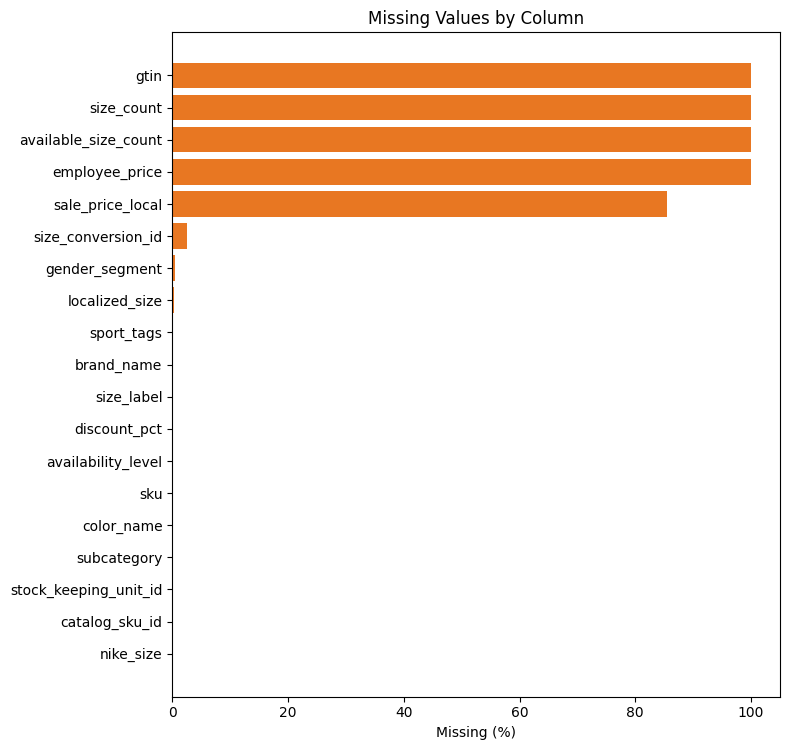

In [9]:
missing = schema[schema['null'] > 0][['null', 'null_%']].sort_values('null_%', ascending=False)

if missing.empty:
    print('No missing values found.')
else:
    print(f'{len(missing)} columns have missing values:\n')
    display(missing)

    fig, ax = plt.subplots(figsize=(8, max(3, len(missing) * 0.4)))
    ax.barh(missing.index, missing['null_%'], color='#e87722')
    ax.set_xlabel('Missing (%)')
    ax.set_title('Missing Values by Column')
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()

### 3.3 Numeric Columns — Descriptive Statistics & Outliers

In [10]:
num_cols = df.select_dtypes(include='number').columns.tolist()
print(f'Numeric columns ({len(num_cols)}): {num_cols}\n')

if num_cols:
    desc = df[num_cols].describe().T
    desc['IQR'] = desc['75%'] - desc['25%']
    desc['outlier_low']  = desc['25%'] - 1.5 * desc['IQR']
    desc['outlier_high'] = desc['75%'] + 1.5 * desc['IQR']
    display(desc)

Numeric columns (8): ['price_local', 'sale_price_local', 'size_count', 'available_size_count', 'discount_pct', 'employee_price', 'gtin', 'stock_keeping_unit_id']



,count,mean,std,min,25%,50%,75%,max,IQR,outlier_low,outlier_high
price_local,"1,447,795.00","65,554.76","438,649.77",0.00,74.99,139.99,629.99,"10,799,000.00",555.00,-757.51,"1,462.49"
sale_price_local,"210,687.00","136,031.43","635,413.78",8.99,109.99,369.00,"3,149.00","10,309,000.00","3,039.01","-4,448.53","7,707.52"
size_count,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
available_size_count,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
discount_pct,"1,447,777.00",3.60,9.17,-20.27,0.00,0.00,0.00,50.82,0.00,0.00,0.00
employee_price,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gtin,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
stock_keeping_unit_id,"1,447,793.00","903,250,348.38","298,475,917.07","10,007,015.00","1,004,106,332.00","1,005,085,783.00","1,005,424,449.00","1,007,658,420.00","1,318,117.00","1,002,129,156.50","1,007,401,624.50"


In [11]:
# Count IQR outliers per numeric column
if num_cols:
    outlier_counts = {}
    for col in num_cols:
        q1, q3 = df[col].quantile(0.25), df[col].quantile(0.75)
        iqr = q3 - q1
        mask = (df[col] < q1 - 1.5*iqr) | (df[col] > q3 + 1.5*iqr)
        outlier_counts[col] = mask.sum()

    outlier_df = pd.Series(outlier_counts, name='outlier_count').to_frame()
    outlier_df['outlier_%'] = (outlier_df['outlier_count'] / len(df) * 100).round(2)
    outlier_df = outlier_df[outlier_df['outlier_count'] > 0].sort_values('outlier_%', ascending=False)

    if outlier_df.empty:
        print('No IQR outliers detected.')
    else:
        print('Columns with IQR outliers:')
        display(outlier_df)

Columns with IQR outliers:


,outlier_count,outlier_%
price_local,249672,17.24
discount_pct,210796,14.56
stock_keeping_unit_id,200807,13.87
sale_price_local,34906,2.41


### 3.4 Categorical Columns — Cardinality & Top Values

In [12]:
cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
print(f'Categorical columns ({len(cat_cols)}): {cat_cols}\n')

for col in cat_cols:
    n_unique = df[col].nunique()
    top = df[col].value_counts(dropna=False).head(10)
    print(f'--- {col} ({n_unique} unique values) ---')
    display(top.to_frame('count').assign(pct=(top / len(df) * 100).round(2)))
    print()

Categorical columns (24): ['snapshot_date', 'country_code', 'product_name', 'model_number', 'currency', 'gender_segment', 'size_label', 'category', 'subcategory', 'product_id', 'sku', 'style_color', 'brand_name', 'color_name', 'availability_level', 'product_url', 'canonical_url', 'image_url', 'catalog_sku_id', 'nike_size', 'localized_size', 'size_conversion_id', 'sport_tags', 'record_source']

--- snapshot_date (1 unique values) ---


,count,pct
snapshot_date,,
2026-03-19,1447795,100.00



--- country_code (45 unique values) ---


,count,pct
country_code,,
US,69949,4.83
LU,45053,3.11
IE,44064,3.04
JP,43306,2.99
BE,43090,2.98
NL,42622,2.94
SI,42065,2.91
AT,41197,2.85
PT,40144,2.77



--- product_name (15721 unique values) ---


...

,count,pct
size_conversion_id,,
634c88b1-1341-378c-91c2-694b4d4af924,43888,3.03
cb181d5c-38b4-3423-a1a4-aa7d8c6f0bc7,43884,3.03
63c009fa-41e9-37f7-8207-2131d668fc30,43860,3.03
ee441df8-f44d-3452-abf3-80619a6b7376,43854,3.03
7c41b818-d111-3baf-a3d9-2f0a21a35ff5,42326,2.92
NaN,36820,2.54
4e8ef2e4-8a7b-3460-b92e-f5879b278014,29290,2.02
c8e7b399-3c8c-3fd3-93d3-b78b1c1b06af,24664,1.70
8a7e7852-e4c0-3a54-88d6-392eb418754e,23887,1.65



--- sport_tags (348 unique values) ---


,count,pct
sport_tags,,
Lifestyle,662790,45.78
Soccer,206755,14.28
Basketball,113158,7.82
Running,94283,6.51
Workouts|Training & Gym,68010,4.70
Golf,37776,2.61
Lifestyle|Basketball,27982,1.93
Tennis,19985,1.38
Running|Track & Field,17120,1.18



--- record_source (2 unique values) ---


,count,pct
record_source,,
thread_exact,1447793,100.00
market_only,2,0.00


### 3.5 Date/Time Columns

In [13]:
# Auto-detect likely date columns
date_candidates = [c for c in df.columns if any(kw in c.lower() for kw in ['date', 'time', 'year', 'month', 'week'])]

if not date_candidates:
    print('No obvious date columns detected by name. Check manually if needed.')
else:
    for col in date_candidates:
        try:
            parsed = pd.to_datetime(df[col], errors='coerce')
            n_parsed = parsed.notna().sum()
            print(f'{col}: {n_parsed:,}/{len(df):,} parsed as dates | range: {parsed.min()} → {parsed.max()}')
        except Exception as e:
            print(f'{col}: could not parse — {e}')

snapshot_date: 1,447,795/1,447,795 parsed as dates | range: 2026-03-19 00:00:00 → 2026-03-19 00:00:00


## 4. Distributions of Numeric Columns

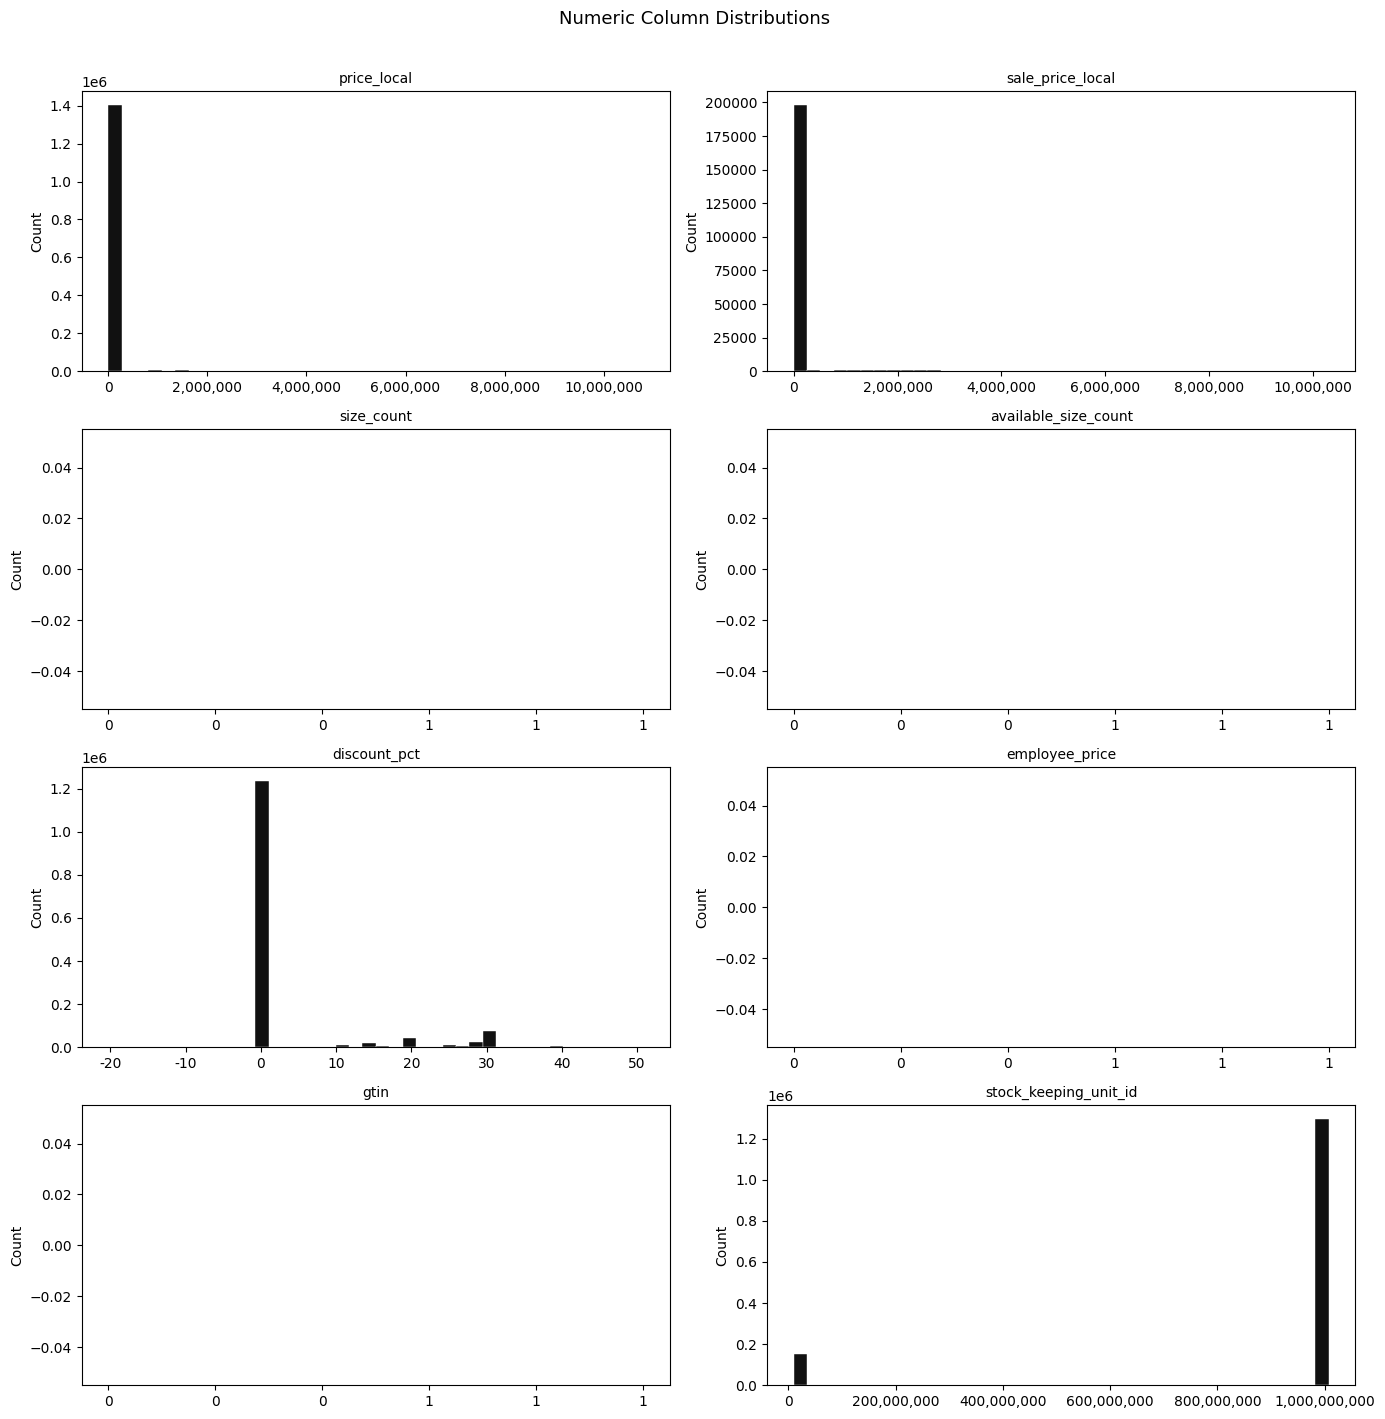

In [14]:
if num_cols:
    n = len(num_cols)
    ncols = 2
    nrows = (n + 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(14, nrows * 3.5))
    axes = axes.flatten()

    for i, col in enumerate(num_cols):
        data = df[col].dropna()
        axes[i].hist(data, bins=40, color='#111111', edgecolor='white', linewidth=0.3)
        axes[i].set_title(col, fontsize=10)
        axes[i].set_ylabel('Count')
        axes[i].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.suptitle('Numeric Column Distributions', fontsize=13, y=1.01)
    plt.tight_layout()
    plt.show()

## 5. Correlation Matrix (Numeric Columns)

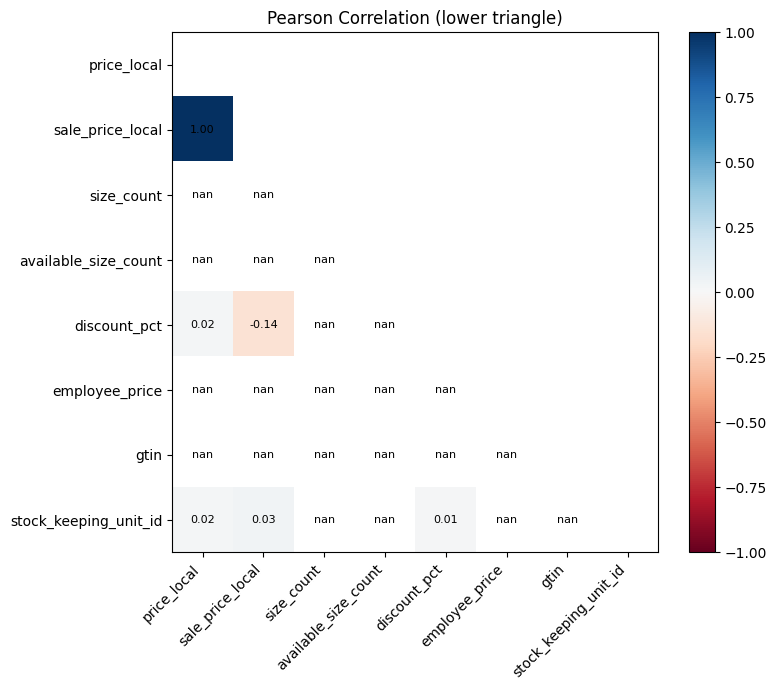

In [15]:
if len(num_cols) > 1:
    corr = df[num_cols].corr()
    mask = np.triu(np.ones_like(corr, dtype=bool))

    fig, ax = plt.subplots(figsize=(max(6, len(num_cols)), max(5, len(num_cols) - 1)))
    im = ax.imshow(corr.where(~mask, other=np.nan), cmap='RdBu', vmin=-1, vmax=1, aspect='auto')
    plt.colorbar(im, ax=ax)

    ax.set_xticks(range(len(num_cols)))
    ax.set_yticks(range(len(num_cols)))
    ax.set_xticklabels(num_cols, rotation=45, ha='right')
    ax.set_yticklabels(num_cols)

    for i in range(len(num_cols)):
        for j in range(len(num_cols)):
            if not mask[i, j]:
                ax.text(j, i, f'{corr.iloc[i, j]:.2f}', ha='center', va='center', fontsize=8)

    ax.set_title('Pearson Correlation (lower triangle)')
    plt.tight_layout()
    plt.show()
else:
    print('Need at least 2 numeric columns for correlation.')

## 6. Quality Summary

In [16]:
print('=' * 50)
print('DATA QUALITY SUMMARY')
print('=' * 50)
print(f'Rows:              {len(df):,}')
print(f'Columns:           {len(df.columns)}')
print(f'Duplicate rows:    {df.duplicated().sum():,}')
print(f'Columns w/ nulls:  {(df.isna().any()).sum()}')
print(f'Total null cells:  {df.isna().sum().sum():,} ({df.isna().mean().mean()*100:.2f}% of all cells)')
print(f'Numeric columns:   {len(num_cols)}')
print(f'Categorical cols:  {len(cat_cols)}')
print(f'Date candidates:   {len(date_candidates)}')

DATA QUALITY SUMMARY
Rows:              1,447,795
Columns:           35
Duplicate rows:    0
Columns w/ nulls:  19
Total null cells:  7,077,914 (13.97% of all cells)
Numeric columns:   8
Categorical cols:  24
Date candidates:   1
